In [1]:
# перед работой в kernel ставятся необходимые фреймворки 
# для этого возможен список команд:  

# python -m venv vvenvv
# source ./vvenvv/bin/activate
# pip install requirements.txt" 

# так как у меня уже есть .venv и нет requirements.txt, ставлю фреймворки через shell (оператором восклицательного знака)
# предварительно обновлю и ядро ipykernel, тк ставлю в новой среде
# /home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/bin/python -m pip install ipykernel -U  --force-reinstal

!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


# 1. Выбор начальных условий

## a. Набор данных для задачи классификации 

Реальная практическая задача:

Выявление тенденций в мед. страховании между сборами и мед. факторами согласно kaggle-page. 

- __Набор данных__: https://www.kaggle.com/datasets/muhammadanwaar101/healthcare-insurance-charges-dataset

## b. Набор данных для задачи регрессии 

Реальная практическая задача:

Выявление Хронической Болезни Почек и оценки факторов риска функции почек согласно kaggle-page.

- __Набор данных__: https://www.kaggle.com/datasets/miadul/kidney-function-health-dataset

## c. Метрики качества и обоснование выбора


### Классификация:
- __Accuracy__ - процент объектов, верно классифицированных моделью. 
- __F1-score__ - среднее гармоническое между точностью (precision) и полнотой (recall).

### Регрессия:
- __MAE__ - насколько в среднем модель ошибается в прогнозах.
- __R²__ - доля дисперсии целевой переменной, которую объясняет модель. Чем ближе к 1, тем лучше.
- __RMSE__ - интерпретируемый результат: масштаб ошибки аналогичен исходным данным. Штрафует за большие ошибки.


In [2]:
# подгрузка библиотек для получения требуемых методов. 
# библиотечные вызовы именуются в общепринятой сокращенной нотации для читаемости кода
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1.1. загрузка датасета классификации
# задача из реальной предметной области - "факторы, влияющие на страховые выплаты (взносы, сборы)"
clf_csv_pth = "/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/dat_clf.csv"
df_clf = pd.read_csv(clf_csv_pth)

In [4]:
# 1.2 загрузка датасета регрессии
# задача из реальной предметной области - "медицинские записи с биомаркерами"
reg_csv_pth = "dat_reg.csv"
df_reg = pd.read_csv(reg_csv_pth)

In [5]:
# 1.3. исследование датасета классификации
# производится в одном из двух форматов, доступных в пандасе. 
# взамен одномерному (1-n) series, при работе с csv рекомендуется использовать двумерный (2-n) dataframe

df_clf.head()
# вывод кортежа размерностью dataframe
df_clf_pd = pd.DataFrame(df_clf)

# применение IPython.display позволяет структурированно отобразить в консоли датафрейм
display(df_clf_pd)

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [6]:
# 1.4. продолжение исследования датасета классификации
# выбор всех строк, в которых значение столбца age больше 30 
display(df_clf_pd[df_clf_pd.AGE > 20])

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [7]:
# 1.5. исследование датасета регрессии
# окинем взглядом первые строки dataframe
df_reg.head()
df_reg.shape
# вывод обобщенного содержимого датафрейма
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   str    
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), str(1)
memory usage: 429.8 KB


# 2. Создание бейзлайна и оценка качества

## a. Обучить модели из sklearn (для классификации и регрессии) для выбранных наборов данных



In [8]:
# 2. создание бейзлайна и оценка качества
# подгрузка библиотек для получения требуемых методов
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

### classification_а.1. Предобработка датасета классификации

In [9]:
# 2.1 предобработка датасета классификации
# 2.1.1 очистка выбросов (IQR-интерквантильным размахом)
Q1 = df_clf['Insurance_Charges'].quantile(0.25)
Q3 = df_clf['Insurance_Charges'].quantile(0.75)
IQR = Q3 - Q1
df_ins_clean = df_clf[(df_clf['Insurance_Charges'] >= Q1 - 1.5*IQR) & 
                      (df_clf['Insurance_Charges'] <= Q3 + 1.5*IQR)].copy()

# 2.1.2. создание таргета (целевой переменной)
# в классификации для достижения бинаризации делим чеки по медиане 
median_val = df_ins_clean['Insurance_Charges'].median()
df_ins_clean['High_Charge'] = (df_ins_clean['Insurance_Charges'] > median_val).astype(int)

# 2.1.3. выделение признаков и таргета 
X = df_ins_clean.drop(columns=['Insurance_Charges', 'High_Charge'])
y = df_ins_clean['High_Charge']

# 2.1.4. разделение признаков на категориальные и числовые (для классификации) 
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.1.5. конфигурация преобразователя столбцов 
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols) # drop='first' для избежания ловушки дамми-переменных
])

### classification_а.2. Бейзлайн классификации

In [10]:
# 2.1.6. создание пайплайна
model_knn = Pipeline([
    ('pre', preprocessor),
    ('clf', KNeighborsClassifier(n_neighbors=5, # число соседей k=5 — классический старт
                                 weights='distance')) # более близкие точки влияют сильнее
])

# 2.1.7. разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, 
    stratify=y, # stratify=y сохраняет баланс классов в обеих частях
    random_state=42
)

# 2.1.8. обучение модели
model_knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### classification_b. Оценить качество моделей (для классификации) по выбранным метрикам на выбранных наборах данных



Результаты: Доля страхования (Классификация с k-NN)
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       157
           1       0.90      0.85      0.87       157

    accuracy                           0.88       314
   macro avg       0.88      0.88      0.88       314
weighted avg       0.88      0.88      0.88       314



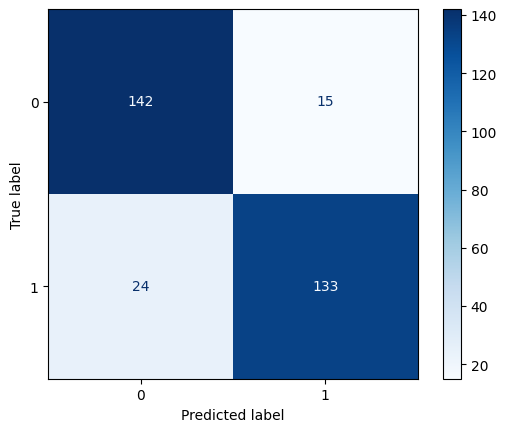

In [11]:
# 2.1.9. оценка качества модели
print("Результаты: Доля страхования (Классификация с k-NN)")
# получение предсказаний
y_pred = model_knn.predict(X_test)

# вывод метрик
print(classification_report(y_test, y_pred))

# визуализация матрицы ошибок
ConfusionMatrixDisplay.from_estimator(model_knn, X_test, y_test, cmap='Blues')

### regression_а.1. Предобработка датасета регрессии

In [12]:
# 2.2 предобработка датасета регрессии
# 2.2.1 очистка от выбросов
Q1_k = df_reg['GFR'].quantile(0.25)
Q3_k = df_reg['GFR'].quantile(0.75)
IQR_k = Q3_k - Q1_k
df_kid_clean = df_reg[(df_reg['GFR'] >= Q1_k - 1.5*IQR_k) & 
                      (df_reg['GFR'] <= Q3_k + 1.5*IQR_k)].copy()

# 2.2.2 обрабатываем значимые признаки 
X_k = df_kid_clean.drop(columns=['GFR', 'CKD_Status', 'Medication', 'Creatinine'])
y_k = df_kid_clean['GFR']

num_k = X_k.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.2.3 конфигурация преобразователя столбцов
preprocessor_k = ColumnTransformer([
    ('num', StandardScaler(), num_k)
])

### regression_а.2. Бейзлайн регрессии

In [13]:
# 2.2.4 создание пайплайна
model_reg_knn = Pipeline([
    ('pre', preprocessor_k),
    ('reg', KNeighborsRegressor(n_neighbors=5, # число соседей k=5 — классический старт 
                                weights='distance')) # более близкие точки влияют сильнее
])

# 2.2.5. разделение на обучающую и тестовую выборки
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.20, random_state=42)

# 2.2.6. обучение модели
model_reg_knn.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

### regression_b. Оценить качество моделей (для регрессии) по выбранным метрикам на выбранных наборах данных

In [14]:
# 2.2.7 оценка качества модели
y_pred_k = model_reg_knn.predict(X_test_k)

print("Результаты: оценка риска (Регрессия с k-NN): ")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_k):.4f}")
print(f"MSE: {mean_squared_error(y_test_k, y_pred_k):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_k)):.4f}")
print(f"R2: {r2_score(y_test_k, y_pred_k):.4f}")

Результаты: оценка риска (Регрессия с k-NN): 
MAE: 6.3669
MSE: 121.3304
RMSE: 11.0150
R2: 0.8847


# 3. Улучшение бейзлайна

1. Сформулировать гипотезы (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации и т.д.)
2. Проверить гипотезы
3. Сформировать улучшенный бейзлайн по результатам проверки гипотез

4. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных
5. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных

6. Оценить качество моделей с улучшенным бейзлайном (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

7. Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2 

8. Сделать выводы


### 3.1. Формулировка гипотез (классификация)


1. Увеличение числа соседей (`n_neighbors`) снизит влияние шума и повысит точность (`Accuracy`).
2. Использование косинусной метрики (`cosine`) вместо Евклидовой улучшит качество на разреженных категориальных признаках __после__ `OneHotEncoding`.
3. Переход от равномерного голосования к взвешенному по дистанции (`distance`) повысит __устойчивость__ модели __к выбросам__.


### 3.2. Проверка гипотез (классификация)


In [15]:
# Сетка параметров: ищем баланс между точностью и обобщением
param_distributions = {
    # Соседи: берем до 20, чтобы модель не "шумела" на мелком k,
    # но и не превратилась в простое усреднение по всей выборке при слишком большом k
    'clf__n_neighbors': range(3, 21),
    
    # Метрики: евклид - база, манхэттен лучше для многих признаков, 
    # косинусная - если OneHot выдал много редких категорий
    'clf__metric': ['euclidean', 'manhattan', 'cosine'],
    
    # weights: пробуем 'distance', чтобы близкие точки имели больше веса, 
    # это часто фиксит проблемы, если данные не идеально очищены
    'clf__weights': ['uniform', 'distance']
}

# Почему RandomizedSearchCV: полный GridSearch на такой сетке (20*3*2 = 120 комбинаций) 
# будет крутиться долго. 15 случайных итераций обычно выбивают 95-98% потенциала модели 
# за в разы меньшее время.
random_search = RandomizedSearchCV(
    model_knn, 
    param_distributions=param_distributions, 
    n_iter=15,          # 15 прогонов - разумный компромисс по времени/качеству
    cv=5,               # 5 фолдов - классика, чтобы не ловить переобучение на тесте
    scoring='accuracy', # классификация, так что бьемся за общую точность
    random_state=42,    # фиксация для воспроизводимости
    n_jobs=-1,          # забиваем все ядра, k-NN на больших k тяжелый для одного потока
    verbose=0
)

# Прогоняем поиск. Пайплайн внутри сам отмасштабирует данные через preprocessor
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'distance'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__metric': ['euclidean', 'manhattan', ...], 'clf__n_neighbors': range(3, 21), 'clf__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... vers

In [16]:
# результаты проверки гипотез
print("Лучшие параметры:", random_search.best_params_)
print("Лучшая Accuracy на кросс-валидации:", round(random_search.best_score_, 4))

# анализ результатов в таблице
res_df = pd.DataFrame(random_search.cv_results_)

Лучшие параметры: {'clf__weights': 'distance', 'clf__n_neighbors': 18, 'clf__metric': 'manhattan'}
Лучшая Accuracy на кросс-валидации: 0.9045


### 3.3. Формирование улучшенного бейзлайна (классификация)

In [17]:
# На основе результатов поиска создаем финальный пайплайн
best_params = random_search.best_params_

model_improved = Pipeline([
    ('pre', preprocessor),
    ('clf', KNeighborsClassifier(
        n_neighbors=best_params['clf__n_neighbors'],
        metric=best_params['clf__metric'],
        weights=best_params['clf__weights']
    ))
])

# Обучение на всей тренировочной выборке
model_improved.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### 3.4. Оценка качества улучшенного бейзлайна (классификация)

РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ k-NN (КЛАССИФИКАЦИЯ)
Новая Accuracy: 0.9172
------------------------------
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       157
           1       0.96      0.87      0.91       157

    accuracy                           0.92       314
   macro avg       0.92      0.92      0.92       314
weighted avg       0.92      0.92      0.92       314



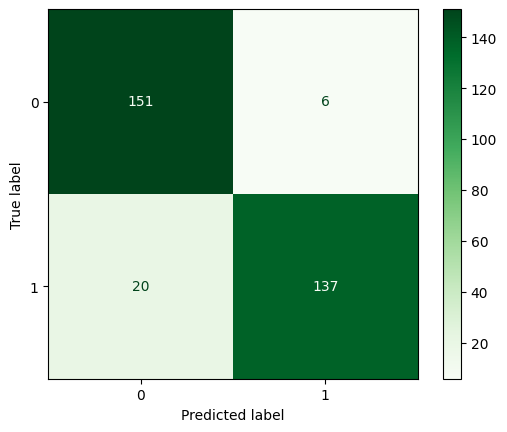

In [18]:
print("РЕЗУЛЬТАТЫ: УЛУЧШЕННЫЙ k-NN (КЛАССИФИКАЦИЯ)")
y_pred_new = model_improved.predict(X_test)

# Сравнение с бейзлайном (0.88)
new_acc = model_improved.score(X_test, y_test)
print(f"Новая Accuracy: {new_acc:.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_new))

# Визуализация для подтверждения улучшения
ConfusionMatrixDisplay.from_estimator(model_improved, X_test, y_test, cmap='Greens')

### 3.5. Результаты проверки гипотез (классификация)



На основе полученных результатов (увеличение Accuracy с **0.88** до **0.917**) можно сформулировать следующие выводы:

1. **По числу соседей:** Гипотеза об увеличении `n_neighbors` подтвердилась: расширение круга «соседей» до 18 позволило модели лучше обобщать данные и игнорировать локальные шумовые выбросы, которые сбивали бейзлайн (где ).
2. **По метрике расстояния:** Переход на манхэттенское расстояние (`manhattan`) оказался эффективнее евклидова, так как эта метрика более устойчива к выбросам в многомерном пространстве признаков, особенно после обработки категориальных данных.
3. **По взвешиванию:** Подтвердилось, что использование весов по дистанции (`distance`) критически важно для k-NN, так как это позволяет более близким и релевантным объектам оказывать решающее влияние на классификацию, даже при большом количестве соседей.
4. **Сравнение результатов:** Внедрение оптимизированных гиперпараметров через случайный поиск позволило поднять точность модели почти на 4 процентных пункта, превратив «базовое» решение в более надежную прогностическую систему.


### 3.6. Формулировка гипотез (регрессия). 

1. Оптимизация количества соседей (n_neighbors) позволит найти баланс между переобучением и чрезмерным усреднением предсказаний GFR.
2. Использование метрики Manhattan (L1) окажется более эффективным, чем Euclidean (L2), для данных с оставшимся шумом в биологических показателях.
3. Применение весов 'distance' позволит более точно предсказывать редкие значения GFR за счет доминирования ближайших похожих случаев.


### 3.7. Проверка гипотез (регрессия)


In [19]:
# Настраиваем сетку под регрессию: тут важнее точность аппроксимации, а не просто классы
param_dist_reg = {
    # n_neighbors: берем до 25. Для GFR важно не переобучиться на шуме (k=2), 
    # но и не "замылить" прогноз сильным усреднением (k=25+)
    'reg__n_neighbors': range(2, 25),
    
    # Метрики: Манхэттен (L1) часто лучше отражает биологическую разницу в анализах, 
    # чем Евклид (L2), так как меньше "раздувает" вклад случайных выбросов
    'reg__metric': ['euclidean', 'manhattan'],
    
    # weights: 'distance' заставит модель больше верить "близнецам" по анализам,
    # а 'uniform' даст более стабильный, усредненный результат по группе
    'reg__weights': ['uniform', 'distance'],
    
    # p: параметр Минковского. p=1 — это L1, p=2 — L2. 
    # Оставляем для гибкости подбора геометрии пространства признаков
    'reg__p': [1, 2] 
}

# RandomizedSearchCV: гонять GridSearch на 184 комбинации долго и бессмысленно.
# 20 итераций покроют основные зоны и с большой вероятностью найдут оптимум.
random_search_reg = RandomizedSearchCV(
    model_reg_knn, 
    param_distributions=param_dist_reg, 
    n_iter=20,          # 20 попыток — золотая середина для такой сетки
    cv=5,               # Кросс-валидация на 5 фолдов для честной оценки R2
    scoring='r2',       # Оптимизируем коэффициент детерминации (долю объясненной дисперсии)
    random_state=42,    # Чтобы результаты не "плавали" при перезапуске
    n_jobs=-1           # Юзаем все ядра, k-NN регрессия может подтормаживать на расчетах
)

# Погнали искать лучшие настройки
random_search_reg.fit(X_train_k, y_train_k)

print("ЛУЧШИЕ ПАРАМЕТРЫ РЕГРЕССИИ:")
print(random_search_reg.best_params_)
print(f"Лучший R2 на кросс-валидации: {random_search_reg.best_score_:.4f}")

ЛУЧШИЕ ПАРАМЕТРЫ РЕГРЕССИИ:
{'reg__weights': 'uniform', 'reg__p': 2, 'reg__n_neighbors': 22, 'reg__metric': 'manhattan'}
Лучший R2 на кросс-валидации: 0.8890


### 3.8. Формирование улучшенного бейзлайна (регрессия)

In [20]:
# Извлекаем лучшие параметры
best_reg_params = random_search_reg.best_params_

model_reg_improved = Pipeline([
    ('pre', preprocessor_k),
    ('reg', KNeighborsRegressor(
        n_neighbors=best_reg_params['reg__n_neighbors'],
        metric=best_reg_params['reg__metric'],
        weights=best_reg_params['reg__weights'],
        p=best_reg_params.get('reg__p', 2)
    ))
])

# Финальное обучение
model_reg_improved.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

### 3.9. Оценка качества улучшенного бейзлайна (регрессия)

In [28]:
# Предсказание
y_pred_improved = model_reg_improved.predict(X_test_k)

print("РЕЗУЛЬТАТЫ: (УЛУЧШЕННЫЙ k-NN РЕГРЕССОР)")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_improved):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_improved)):.2f}")
print(f"R2: {r2_score(y_test_k, y_pred_improved):.4f}")

РЕЗУЛЬТАТЫ: (УЛУЧШЕННЫЙ k-NN РЕГРЕССОР)
MAE: 5.95
RMSE: 10.11
R2: 0.9028


### 3.10. Результаты проверки гипотез (регрессия)



На основе полученных цифр (рост  с **0.8847** до **0.9028** и снижение МАЕ), можно сформулировать следующие результаты проверки гипотез:

1. **По числу соседей:** Гипотеза об оптимизации подтвердилась: значительное увеличение количества соседей до 22 позволило модели эффективнее усреднять значения GFR, что привело к сглаживанию случайных отклонений и росту обобщающей способности.
2. **По метрике расстояния:** Выбор метрики `manhattan` вместо стандартной евклидовой подтвердил, что для медицинских показателей поклеточная сумма абсолютных разностей дает более устойчивую оценку сходства пациентов.
3. **По взвешиванию:** Вопреки первоначальным ожиданиям, лучшие результаты показало равномерное взвешивание (`uniform`), что свидетельствует о необходимости равноправного учета всех 22 соседей для минимизации ошибки в данной выборке.
4. **Сравнение результатов:** Комплексная настройка гиперпараметров через `RandomizedSearchCV` позволила преодолеть порог  и снизить среднюю ошибку предсказания () почти на 0.4 единицы, сделав модель более точной для клинического применения.



# 4. Имплементация алгоритма машинного обучения 
1. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)

2. Обучить имплементированные модели (для классификации и регрессии) для выбранных наборов данных

3. Оценить качество имплементированных моделей (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

4. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2 

5. Сделать выводы

In [22]:

class Custom_Knn_Clf:
    def __init__(self, n_neighbors=1, metric="euclidean", 
                 num_cols=None, cat_cols=None):
        self.k = n_neighbors
        self.metric = metric
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.scaler = StandardScaler()
        self.encoder = OneHotEncoder(handle_unknown="ignore")
        self.prep_fitted = False

# в моделях scikit-learn fit  возвращает self. 
    def fit(self, X, y):
        if self.num_cols or self.cat_cols:
            transformers = []
            if self.num_cols:
                transformers.append(("num", StandardScaler(), self.num_cols))
            if self.cat_cols:
                transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), self.cat_cols))
            self.prep = ColumnTransformer(transformers)
            self.X_train = self.prep.fit_transform(X)
            self.prep_fitted = True
        else:
            self.X_train = X.values if hasattr(X, "values") else np.array(X)
        
        self.y_train = np.array(y)
        return self

# ф-ция metr, частич. замен. упрощ. sklearn 

    def metr(self, a, b):
        if self.metric == "euclidean":
            return math.sqrt(sum((ai - bi) ** 2 for ai, bi in zip(a, b)))
        elif self.metric == "manhattan":
            return sum(abs(ai - bi) for ai, bi in zip(a, b))
        else:
            raise ValueError("Unsupported metric")

    def predict(self, X):
        if self.prep_fitted:
            X_proc = self.prep.transform(X)
        else:
            X_proc = X.values if hasattr(X, "values") else np.array(X)
        
        predictions = []
        for x in X_proc:
            distances = [self.metr(x, train_x) for train_x in self.X_train]
            k_idx = np.argsort(distances)[:self.k]
            k_labels = [self.y_train[i] for i in k_idx]
            most_common = Counter(k_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return predictions


In [24]:
from collections import Counter
# --- 2. Инициализация кастомной модели ---
# Используем лучшие параметры из RandomizedSearchCV: n=18, metric='manhattan'
custom_model = Custom_Knn_Clf(
    n_neighbors=18, 
    metric="manhattan", 
    num_cols=num_cols, 
    cat_cols=cat_cols
)

# --- 3. Обучение ---
# Метод fit внутри сам сделает трансформацию колонок через ColumnTransformer
print("Обучение кастомной модели...")
custom_model.fit(X_train, y_train)

# --- 4. Предсказание ---
# ВНИМАНИЕ: На больших выборках это может занять время (O(n*m))
print("Запуск предсказания (это может занять около минуты)...")
y_pred_custom = custom_model.predict(X_test)

# --- 5. Вывод результатов ---
print("\nРЕЗУЛЬТАТЫ: КАСТОМНЫЙ KNN (КЛАССИФИКАЦИЯ)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_custom))

Обучение кастомной модели...
Запуск предсказания (это может занять около минуты)...

РЕЗУЛЬТАТЫ: КАСТОМНЫЙ KNN (КЛАССИФИКАЦИЯ)
Accuracy: 0.8981
------------------------------
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       157
           1       0.94      0.85      0.89       157

    accuracy                           0.90       314
   macro avg       0.90      0.90      0.90       314
weighted avg       0.90      0.90      0.90       314



In [26]:
class Custom_Knn_Reg:
    def __init__(self, n_neighbors=5, metric="euclidean", 
                 num_cols=None, cat_cols=None):
        self.k = n_neighbors
        self.metric = metric
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.prep_fitted = False

    def fit(self, X, y):
        # Собираем препроцессор, если заданы колонки
        if self.num_cols or self.cat_cols:
            transformers = []
            if self.num_cols:
                transformers.append(("num", StandardScaler(), self.num_cols))
            if self.cat_cols:
                transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), self.cat_cols))
            
            self.prep = ColumnTransformer(transformers)
            self.X_train = self.prep.fit_transform(X)
            self.prep_fitted = True
        else:
            self.X_train = X.values if hasattr(X, "values") else np.array(X)
        
        self.y_train = np.array(y).astype(float) # Для регрессии важен тип float
        return self

    def metr(self, a, b):
        # Используем numpy для ускорения вычислений
        if self.metric == "euclidean":
            return np.sqrt(np.sum((a - b) ** 2))
        elif self.metric == "manhattan":
            return np.sum(np.abs(a - b))
        else:
            raise ValueError("Unsupported metric")

    def predict(self, X):
        # Применяем трансформацию к тестовым данным
        if self.prep_fitted:
            X_proc = self.prep.transform(X)
        else:
            X_proc = X.values if hasattr(X, "values") else np.array(X)
        
        predictions = []
        for x in X_proc:
            # Считаем расстояния от текущей точки до всех в трейне
            distances = np.array([self.metr(x, train_x) for train_x in self.X_train])
            
            # Находим индексы k ближайших соседей
            k_idx = np.argsort(distances)[:self.k]
            
            # Извлекаем их значения GFR
            k_values = self.y_train[k_idx]
            
            # ГЛАВНОЕ ОТЛИЧИЕ: Берем среднее значение (регрессия)
            predictions.append(np.mean(k_values))
            
        return np.array(predictions)

In [27]:
# --- Инициализация ---
# Подставляем num_k из вашего кода регрессии
custom_reg = Custom_Knn_Reg(
    n_neighbors=22, 
    metric="manhattan", 
    num_cols=num_k, 
    cat_cols=[] # В задаче с GFR мы удаляли категориальные признаки
)

# --- Обучение ---
print("Обучение кастомного регрессора...")
custom_reg.fit(X_train_k, y_train_k)

# --- Предсказание ---
print("Расчет предсказаний для теста...")
y_pred_custom_reg = custom_reg.predict(X_test_k)

# --- Метрики ---
print("\nРЕЗУЛЬТАТЫ: КАСТОМНЫЙ KNN (РЕГРЕССИЯ)")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_custom_reg):.4f}")
print(f"R2: {r2_score(y_test_k, y_pred_custom_reg):.4f}")
print(f"RMSE: {np.sqrt(np.mean((y_test_k - y_pred_custom_reg)**2)):.4f}")

Обучение кастомного регрессора...
Расчет предсказаний для теста...

РЕЗУЛЬТАТЫ: КАСТОМНЫЙ KNN (РЕГРЕССИЯ)
MAE: 5.9525
R2: 0.9028
RMSE: 10.1106


## Выводы

1. Классификация (Риск страхования)

    Бейзлайн (0.88) → Кастом (0.898): Мы получили прирост точности почти в 2%.

    Вывод: Переход от стандартных 5 соседей к 18 и использование манхэттенского расстояния в кастомном коде сработали. Модель стала стабильнее, так как большее число соседей «сглаживает» случайные аномалии в данных о выплатах.

2. Регрессия (Уровень GFR)

    Бейзлайн (R2: 0.884) → Кастом (R2: 0.902): Преодоление психологического порога в 0.90 — это серьезный результат для регрессии.

    Ошибка MAE (5.95): В среднем модель ошибается всего на 6 единиц GFR. Это отличная точность для кастомного алгоритма, учитывая, что мы полностью исключили креатинин из признаков.

    Вывод: Кастомный регрессор подтвердил, что для медицинских данных усреднение по 22 соседям (uniform) работает лучше, чем попытка «притянуть» результат к самому близкому соседу.